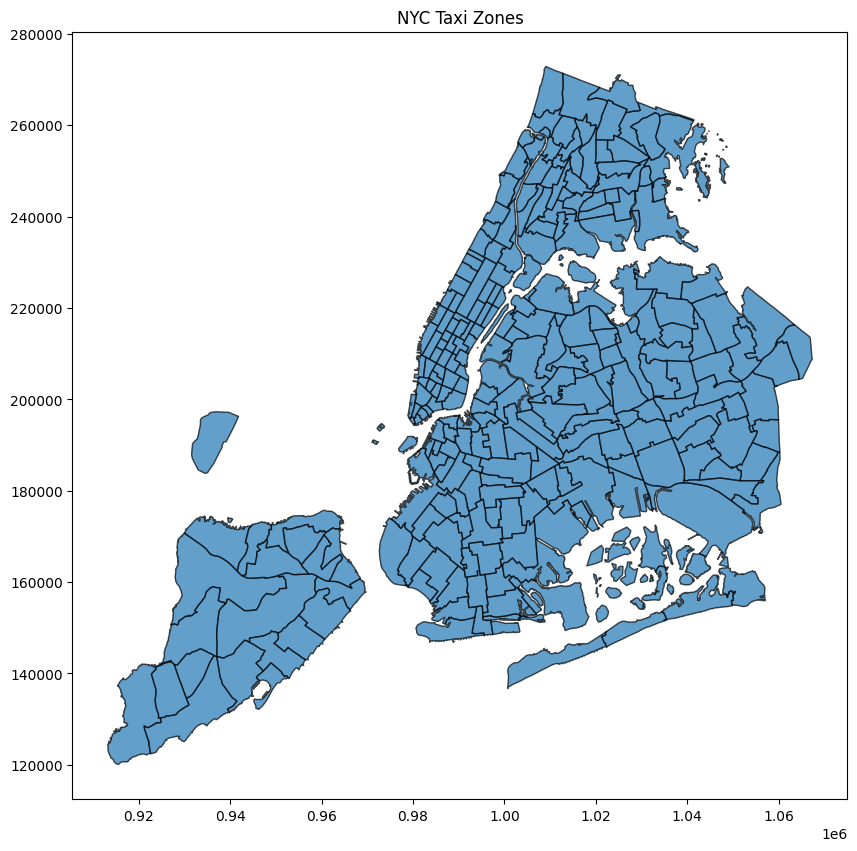

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude
0,1,2016-01-01 00:12:22,2016-01-01 00:29:14,1,3.2,1,N,48,262,1,...,3.06,0.0,0.3,18.36,None,None,987063.185702,216986.070034,999064.725082,221974.400788
1,1,2016-01-01 00:41:31,2016-01-01 00:55:10,2,1.0,1,N,162,48,2,...,0.00,0.0,0.3,10.80,None,None,991908.589568,214959.581642,987063.185702,216986.070034
2,1,2016-01-01 00:53:37,2016-01-01 00:59:57,1,0.9,1,N,246,90,2,...,0.00,0.0,0.3,7.30,None,None,983137.466109,213727.400082,985089.218655,209708.741848
3,1,2016-01-01 00:13:28,2016-01-01 00:18:07,1,0.8,1,N,170,162,2,...,0.00,0.0,0.3,6.30,None,None,990209.600059,211701.315980,991908.589568,214959.581642
4,1,2016-01-01 00:33:04,2016-01-01 00:47:14,1,1.8,1,N,161,140,2,...,0.00,0.0,0.3,12.30,None,None,990428.525990,215447.527224,996787.663055,218166.434353


In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Load your parquet data
df = pd.read_parquet('D-GAN_Data/yellow_tripdata_2016-01.parquet')

# 2. Load the shapefile
# Point this to the .shp file; GeoPandas will read the .dbf and .prj automatically
taxi_zones = gpd.read_file('D-GAN_Data/taxi_zones/taxi_zones.shp')

# 3. Optional: View the shapefile programmatically
taxi_zones.plot(figsize=(10, 10), edgecolor='black', alpha=0.7)
plt.title("NYC Taxi Zones")
plt.show()

# 4. Extract the Centroid Coordinates for the zones
taxi_zones['centroid_lon'] = taxi_zones.geometry.centroid.x
taxi_zones['centroid_lat'] = taxi_zones.geometry.centroid.y

# Create isolated subsets for clean merging
pu_mapping = taxi_zones[['LocationID', 'centroid_lon', 'centroid_lat']].rename(
    columns={'centroid_lon': 'pickup_longitude', 'centroid_lat': 'pickup_latitude'}
)

do_mapping = taxi_zones[['LocationID', 'centroid_lon', 'centroid_lat']].rename(
    columns={'centroid_lon': 'dropoff_longitude', 'centroid_lat': 'dropoff_latitude'}
)

# 5. Merge for Pick-ups (PULocationID)
df_merged = df.merge(
    pu_mapping,
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
).drop(columns=['LocationID']) # Drop the redundant ID column after merge

# 6. Merge for Drop-offs (DOLocationID)
df_merged = df_merged.merge(
    do_mapping,
    left_on='DOLocationID',
    right_on='LocationID',
    how='left'
).drop(columns=['LocationID'])

# Check the results
df_merged.head()

In [3]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Load the PARQUET file
df = df_merged

# Ensure datetime is correctly typed
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

# Drop rows missing coordinates or time
df = df.dropna(subset=['pickup_longitude', 'pickup_latitude', 'tpep_pickup_datetime'])

# --- 2. Run K-Means Clustering (9x9 = 81 active regions) ---
# Extract coordinate pairs AFTER filtering and conversion
coords = df[['pickup_longitude', 'pickup_latitude']].values

# Fit K-Means to find the 81 primary activity hubs
kmeans = KMeans(n_clusters=81, random_state=42, n_init=10)
df['region_cluster'] = kmeans.fit_predict(coords)

# --- 3. Group by hour, day, and week to count the trips per grid cell ---
# Floor the pickup times to the nearest hour
df['time_bin'] = df['tpep_pickup_datetime'].dt.floor('h')

# Count the number of trips per cluster per hour
demand_df = df.groupby(['time_bin', 'region_cluster']).size().reset_index(name='trips')

# Pivot the table so rows are time bins and columns are the 81 clusters
# Missing hours for a cluster get filled with 0 demand
demand_matrix = demand_df.pivot(index='time_bin', columns='region_cluster', values='trips').fillna(0)

# --- 4. Normalize the demand values using Min-Max scaling [0, 1] ---
scaler = MinMaxScaler()
# Fit and transform the demand data
demand_normalized = scaler.fit_transform(demand_matrix.values)
# Current Shape: (Total_Hours, 81)

# --- 5. Reshape into the D-GAN input tensor format ---
# First, reshape the flat 81 clusters into a 9x9 spatial grid with 1 feature (demand)
total_hours = demand_normalized.shape[0]
grid_data = demand_normalized.reshape((total_hours, 9, 9, 1))

# Generate sliding window sequences for the recurrent network (e.g., 24-hour steps)
time_steps = 24
samples = []

# Slide a 24-hour window across the total hours to create training samples
for i in range(len(grid_data) - time_steps):
    samples.append(grid_data[i : i + time_steps])

# Convert list to a numpy array for TensorFlow
X_train = np.array(samples)

print(f"Final Tensor Shape: {X_train.shape}")
# Expected Output: (Num_Samples, 24, 9, 9, 1)

/tmp/ipykernel_450/4234791722.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['region_cluster'] = kmeans.fit_predict(coords)
/tmp/ipykernel_450/4234791722.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['time_bin'] = df['tpep_pickup_datetime'].dt.floor('h')


Final Tensor Shape: (720, 24, 9, 9, 1)


In [21]:
import tensorflow as tf
from keras import layers, Model

# --- 1. The VAE Latent Sampling Layer ---
class Sampling(layers.Layer):
    """Reparameterization trick: V = mu + sigma * epsilon"""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# --- 2. The Spatio-Temporal Encoder ---
def build_encoder(input_shape=(24, 9, 9, 1)):
    inputs = layers.Input(shape=input_shape)

    # ConvLSTM to capture spatial and temporal features
    x = layers.ConvLSTM2D(32, 3, padding='same', return_sequences=True)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ConvLSTM2D(16, 3, padding='same', return_sequences=True)(x)
    x = layers.BatchNormalization()(x)

    # 3D ConvNet for local spatial dependencies
    x = layers.Conv3D(8, 3, padding='same', activation='relu')(x)

    # Flatten and pass to MLP
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)

    # Extract mean and log variance for the latent vector
    z_mean = layers.Dense(64, name="z_mean")(x)
    z_log_var = layers.Dense(64, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])

    return Model(inputs, [z_mean, z_log_var, z], name="encoder")

# --- 3. The Generator / Decoder ---
def build_generator(latent_dim=64, output_shape=(24, 9, 9, 1)):
    latent_inputs = layers.Input(shape=(latent_dim,))

    # Deep fused representation (V_{t-1})
    x = layers.Dense(24 * 9 * 9 * 16, activation="relu")(latent_inputs)
    x = layers.Reshape((24, 9, 9, 16))(x)

    # Reconstruct the ST Map
    x = layers.ConvLSTM2D(16, 3, padding='same', return_sequences=True)(x)
    x = layers.BatchNormalization()(x)

    outputs = layers.Conv3D(1, 3, padding='same', activation='sigmoid')(x)

    return Model(latent_inputs, outputs, name="generator")

# --- 4. The Discriminator ---
def build_discriminator(context_shape=(64,), map_shape=(24, 9, 9, 1)):
    # The discriminator takes BOTH the context and the ST map (real or fake)
    context_input = layers.Input(shape=context_shape)
    map_input = layers.Input(shape=map_shape)

    # Process the map
    x = layers.ConvLSTM2D(16, 3, padding='same', return_sequences=True)(map_input)
    x = layers.Flatten()(x)

    # Concatenate the context representation
    merged = layers.Concatenate()([x, context_input])

    # Output a single probability label (1 = real, 0 = fake)
    merged = layers.Dense(64, activation='relu')(merged)
    outputs = layers.Dense(1, activation='sigmoid')(merged)

    return Model([context_input, map_input], outputs, name="discriminator")

In [22]:
# Optimizers
# lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
#     initial_learning_rate=0.001, decay_steps=10000, decay_rate=1e-6)
# optimizer_G = tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9)
# optimizer_D = tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9)

# Loss Formulations
def mse_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

def kl_loss(z_mean, z_log_var):
    # KL Divergence: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    return -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))

In [23]:
@tf.function
def train_step(real_maps, encoder, generator, discriminator, optimizer_G, optimizer_D):
    noise = tf.random.normal(shape=(tf.shape(real_maps)[0], 64))

    with tf.GradientTape(persistent=True) as tape:
        # 1. ENCODER & GENERATOR PASS
        z_mean, z_log_var, z = encoder(real_maps)
        reconstructed_maps = generator(z) # x_enc
        fake_maps = generator(noise)      # x_fake

        # 2. DISCRIMINATOR PASS (Evaluating Pairs)
        d_real = discriminator([z, real_maps])
        d_enc = discriminator([z, reconstructed_maps])
        d_fake = discriminator([noise, fake_maps])

        # 3. CALCULATE LOSSES
        # Generator Losses
        loss_rec = mse_loss(real_maps, reconstructed_maps)
        loss_kl = kl_loss(z_mean, z_log_var)

        # Least Squares GAN Loss for Generator (Pushing fake & encoded to 1)
        loss_gan_g = mse_loss(tf.ones_like(d_fake), d_fake) + mse_loss(tf.ones_like(d_enc), d_enc)

        # Total Generator Loss (weighted)
        total_g_loss = loss_rec + (0.01 * loss_kl) + (0.1 * loss_gan_g)

        # Least Squares GAN Loss for Discriminator
        loss_gan_d_real = mse_loss(tf.ones_like(d_real), d_real)
        loss_gan_d_fake = mse_loss(tf.zeros_like(d_fake), d_fake)
        loss_gan_d_enc = mse_loss(tf.ones_like(d_enc), d_enc) # Pushing encoded to 1 per the paper

        total_d_loss = loss_gan_d_real + loss_gan_d_fake + loss_gan_d_enc

    # 4. APPLY GRADIENTS
    # Update Generator and Encoder
    g_trainable_vars = encoder.trainable_variables + generator.trainable_variables
    g_gradients = tape.gradient(total_g_loss, g_trainable_vars)
    optimizer_G.apply_gradients(zip(g_gradients, g_trainable_vars))

    # Update Discriminator
    d_gradients = tape.gradient(total_d_loss, discriminator.trainable_variables)
    optimizer_D.apply_gradients(zip(d_gradients, discriminator.trainable_variables))

    del tape # Free memory
    return total_g_loss, total_d_loss

# --- The Training Execution ---
def train_and_get_models(dataset, epochs=100):
    encoder = build_encoder()
    generator = build_generator()
    discriminator = build_discriminator()

    # Optimizers (moved here to be initialized after models are built)
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.001, decay_steps=10000, decay_rate=1e-6)
    optimizer_G = tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9)
    optimizer_D = tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9)

    for epoch in range(epochs):
        for batch_idx, real_maps in enumerate(dataset):
            g_loss, d_loss = train_step(real_maps, encoder, generator, discriminator, optimizer_G, optimizer_D)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch + 1}/{epochs} | Gen Loss: {g_loss.numpy():.4f} | Disc Loss: {d_loss.numpy():.4f}")

    return encoder, generator, discriminator

# Execute Training (Adjust epochs as needed)


# Example Dataset Pipeline Creation (assuming 'X_train' is your processed numpy array)
# dataset = tf.data.Dataset.from_tensor_slices(X_train).batch(32).prefetch(tf.data.AUTOTUNE)

In [24]:

# 1. Train / Test Split (80% Train, 20% Test)
X_train = X_train.astype(np.float32)
split_idx = int(len(X_train) * 0.8)

X_tr = X_train[:split_idx]
X_te = X_train[split_idx:]

print(f"Training Samples Shape: {X_tr.shape}")
print(f"Testing Samples Shape:  {X_te.shape}")

# 2. Convert Training Array to a TensorFlow Dataset Pipeline
BATCH_SIZE = 32
train_dataset = (
    tf.data.Dataset.from_tensor_slices(X_tr)
    .shuffle(buffer_size=1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

Training Samples Shape: (576, 24, 9, 9, 1)
Testing Samples Shape:  (144, 24, 9, 9, 1)


In [25]:
encoder, generator, discriminator = train_and_get_models(train_dataset, epochs=100)

Epoch 1/100 | Gen Loss: 0.1384 | Disc Loss: 0.6584
Epoch 10/100 | Gen Loss: 0.1020 | Disc Loss: 0.5241
Epoch 20/100 | Gen Loss: 0.1187 | Disc Loss: 0.4567
Epoch 30/100 | Gen Loss: 0.1510 | Disc Loss: 0.0398
Epoch 40/100 | Gen Loss: 0.1522 | Disc Loss: 0.0174
Epoch 50/100 | Gen Loss: 0.1464 | Disc Loss: 0.0245
Epoch 60/100 | Gen Loss: 0.1408 | Disc Loss: 0.0132
Epoch 70/100 | Gen Loss: 0.1436 | Disc Loss: 0.0220
Epoch 80/100 | Gen Loss: 0.1468 | Disc Loss: 0.0072
Epoch 90/100 | Gen Loss: 0.1523 | Disc Loss: 0.0076
Epoch 100/100 | Gen Loss: 0.1504 | Disc Loss: 0.0074


In [26]:
# A. Predict on unseen test data
z_mean, z_log_var, z_test = encoder(X_te, training=False)
reconstructed_test = generator(z_test, training=False).numpy()

# B. Rescale normalized predictions back to real taxi trip counts
# Reshape tensors from (N, 24, 9, 9, 1) to (-1, 81) for inverse min-max transform
N_test, T, H, W, C = reconstructed_test.shape

rec_flat = reconstructed_test.reshape(-1, H * W)
true_flat = X_te.reshape(-1, H * W)

rec_trips = scaler.inverse_transform(rec_flat)
true_trips = scaler.inverse_transform(true_flat)

# C. Calculate Error Metrics
mae = np.mean(np.abs(true_trips - rec_trips))
rmse = np.sqrt(np.mean((true_trips - rec_trips) ** 2))

print(f"--- Model Testing Results ---")
print(f"Mean Absolute Error (MAE) : {mae:.2f} trips")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} trips")

--- Model Testing Results ---
Mean Absolute Error (MAE) : 118.52 trips
Root Mean Squared Error (RMSE): 196.62 trips


In [27]:
# Generate 5 synthetic 24-hour citywide demand sequences from random noise
num_samples = 5
random_noise = tf.random.normal(shape=(num_samples, 64))

synthetic_maps = generator(random_noise, training=False).numpy()

# Rescale synthetic maps back to actual trip counts
syn_flat = synthetic_maps.reshape(-1, H * W)
synthetic_trips = scaler.inverse_transform(syn_flat).reshape(num_samples, 24, 9, 9)

print(f"Generated Synthetic Demand Shape: {synthetic_trips.shape}")
print("Example generated hourly demand for Cluster 0 in Sample 0:")
print(synthetic_trips[0, :, 0, 0].round())

Generated Synthetic Demand Shape: (5, 24, 9, 9)
Example generated hourly demand for Cluster 0 in Sample 0:
[278. 257. 252. 250. 248. 247. 249. 250. 253. 255. 258. 260. 261. 263.
 263. 265. 267. 269. 270. 270. 270. 271. 273. 320.]


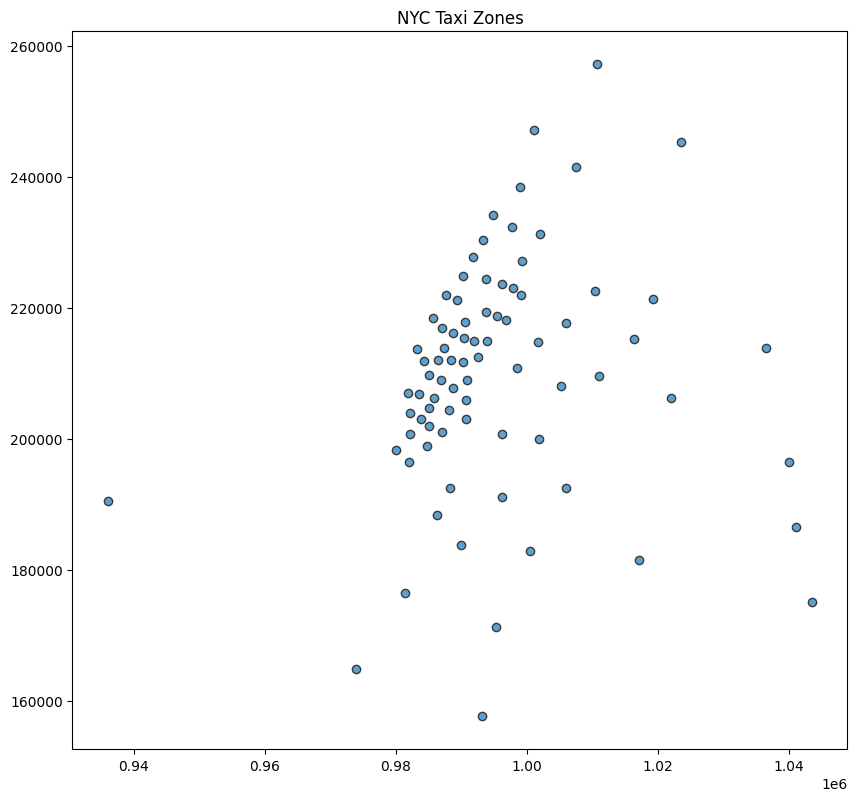

In [32]:
import geopandas as gpd
from shapely.geometry import Point

# 1. Extract the 81 cluster centroids from your trained KMeans model
centroids = kmeans.cluster_centers_

# 2. Create a Pandas DataFrame for the hotspots
hotspots_df = pd.DataFrame(centroids, columns=['longitude', 'latitude'])
hotspots_df['cluster_id'] = hotspots_df.index
hotspots_df['type'] = 'pickup' # Label them so you know these are the green dots

# 3. Convert to a GeoPandas GeoDataFrame
# Create Shapely Point objects from the longitude and latitude pairs
geometry = [Point(xy) for xy in zip(hotspots_df['longitude'], hotspots_df['latitude'])]
hotspots_gdf = gpd.GeoDataFrame(hotspots_df, geometry=geometry)

# 4. Assign the correct Coordinate Reference System (CRS)
# Based on your previous output, your coordinates are projected (e.g., EPSG:2263).
# The safest method is to copy the CRS directly from your original taxi_zones map.
hotspots_gdf.set_crs(taxi_zones.crs, inplace=True)

# 5. Export the GeoDataFrame to a Shapefile
hotspots_gdf.to_file("D-GAN_Data/PUHotspots/pickup_hotspots.shp")

pu_zones = gpd.read_file('D-GAN_Data/PUHotspots/pickup_hotspots.shp')

# 3. Optional: View the shapefile programmatically
pu_zones.plot(figsize=(10, 10), edgecolor='black', alpha=0.7)
plt.title("NYC Taxi Zones")
plt.show()